In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


>>> XGBoost 과적합 차단 및 불균형 조정 최적화 시작...
>>> LightGBM 과적합 차단 및 불균형 조정 최적화 시작...

             [최종 성능 및 불균형 개선 평가 결과]             
✔ XGBoost 최적 하이퍼파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'scale_pos_weight': np.float64(2.2388059701492535), 'subsample': 0.7}
✔ LightGBM 최적 하이퍼파라미터: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_samples': 30, 'n_estimators': 150, 'num_leaves': 3, 'reg_alpha': 1.0, 'reg_lambda': 15.0, 'scale_pos_weight': np.float64(2.2388059701492535), 'subsample': 0.6}

💡 당뇨병 미검출 최소화를 위해 분류 임계값을 0.4로 적용합니다.

[XGBoost Defense Model]
  - Train Set AUC : 0.8949
  - Test Set AUC  : 0.8438
  - AUC 격차(Gap) : 0.0512 ☞ [안정] 일반화 성능이 양호합니다.
  - Accuracy      : 0.7056
  - Precision     : 0.5481
  - Recall (재현율): 0.9136  (★ 환자 포착력 향상 여부 확인)
  - F1-Score      : 0.6852
------------------------------------------------------------
[LightGBM Defense Model]
  - Train Set AUC : 0.8772
  - Test Set AUC  :

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


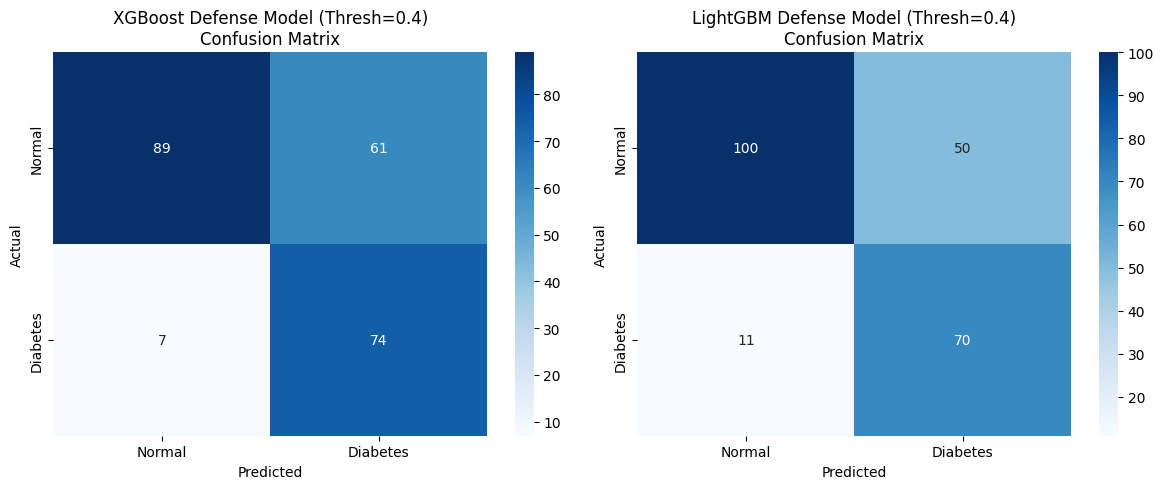

In [3]:
# =========================================================================
# [1단계] 필수 라이브러리 로드
# ========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# =========================================================================
# [2단계] 데이터 로드 및 결측치(0) 정제 처리
# =========================================================================
file_path = '/content/drive/MyDrive/AIAP/diabetes.csv'
df = pd.read_csv(file_path)

# 의학적으로 0이 될 수 없는 변수들을 결측치 처리 대상 지정
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0을 NaN으로 치환하여 분석에서 제외하거나 대체할 준비
df[zero_features] = df[zero_features].replace(0, np.nan)

# 결측치를 각 피처의 중앙값(Median)으로 정밀 대체하여 데이터 손실 최소화
for feature in zero_features:
    median_val = df[feature].median()
    df[feature] = df[feature].fillna(median_val)

# =========================================================================
# [3단계] 피처 엔지니어링 (의학적 도메인 기반 파생 변수 생성)
# =========================================================================
# 1. 인슐린 저항성 및 췌장 과부하 간접 지표
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1e-5)

# 2. 대사증후군 위험도 복합 지표
df['BMI_Age_Product'] = df['BMI'] * df['Age']

# 3. 고령/고혈당 고위험군 타겟 지표
df['Age_Glucose'] = df['Age'] * df['Glucose']

# =========================================================================
# [4단계] 데이터 분할 및 표준화 스케일링
# =========================================================================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 클래스 불균형 비율 계산 (XGBoost scale_pos_weight 기준점)
num_neg = np.sum(y == 0)
num_pos = np.sum(y == 1)
estimated_weight = num_neg / num_pos # 대략 150 / 81 ≒ 1.85

# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 표준화 스케일링 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns

# =========================================================================
# [5단계] XGBoost 과적합 방지 + 불균형 해소형 학습 및 튜닝
# =========================================================================
print(">>> XGBoost 과적합 차단 및 불균형 조정 최적화 시작...")

# 데이터 불균형을 해결하기 위한 scale_pos_weight 파라미터 추가 반영
xgb_strict_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'reg_alpha': [1.0, 2.0, 5.0],       # 과적합 억제를 위해 L1 규제 상향
    'reg_lambda': [5.0, 10.0, 15.0],    # 가중치 폭주 방지를 위해 L2 규제 상향
    'scale_pos_weight': [estimated_weight, estimated_weight * 1.2], # 당뇨 클래스 가중치
    'n_estimators': [100, 150]
}

base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
# 불균형 데이터 셋에서 우수한 환자 감지력을 보장하기 위해 scoring='f1' 설정
grid_xgb = GridSearchCV(estimator=base_xgb, param_grid=xgb_strict_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_

# =========================================================================
# [6단계] LightGBM 과적합 방지 + 불균형 해소형 학습 및 튜닝
# =========================================================================
print(">>> LightGBM 과적합 차단 및 불균형 조정 최적화 시작...")

lgb_strict_grid = {
    'max_depth': [2, 3],
    'num_leaves': [3, 5],
    'min_child_samples': [30, 40, 50],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.6, 0.7],
    'reg_alpha': [1.0, 2.0, 5.0],       # L1 규제 상향
    'reg_lambda': [5.0, 10.0, 15.0],    # L2 규제 상향
    'scale_pos_weight': [estimated_weight, estimated_weight * 1.2], # 당뇨 클래스 가중치
    'n_estimators': [100, 150]
}

base_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1)
# scoring='f1'을 기준으로 리프 노드가 과도하게 Normal에 쏠리는 현상 방지
grid_lgb = GridSearchCV(estimator=base_lgb, param_grid=lgb_strict_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lgb.fit(X_train_scaled, y_train)

best_lgb = grid_lgb.best_estimator_

# =========================================================================
# [7단계] 최종 모델 검증 및 과적합/불균형 개선 평가 (임계값 튜닝 인터페이스 적용)
# =========================================================================
print("\n" + "="*60)
print("             [최종 성능 및 불균형 개선 평가 결과]             ")
print("="*60)
print(f"✔ XGBoost 최적 하이퍼파라미터: {grid_xgb.best_params_}")
print(f"✔ LightGBM 최적 하이퍼파라미터: {grid_lgb.best_params_}\n")

models = [('XGBoost Defense Model', best_xgb), ('LightGBM Defense Model', best_lgb)]

# 🚨 임계값(Threshold) 설정: 0.5에서 0.4로 낮추어 미검출 환자(FN)를 적극 포착
CUSTOM_THRESHOLD = 0.40
print(f"💡 당뇨병 미검출 최소화를 위해 분류 임계값을 {CUSTOM_THRESHOLD}로 적용합니다.\n")

for name, model in models:
    # 확률 예측값 추출
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    # 설정한 임계값(CUSTOM_THRESHOLD) 기준으로 최종 이진 분류 결정
    y_pred_custom = (y_test_proba >= CUSTOM_THRESHOLD).astype(int)

    # 과적합 검증용 AUC 격차 계산 (AUC는 임계값 변화에 영향을 받지 않는 고유 지표)
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)
    auc_gap = train_auc - test_auc

    # 커스텀 임계값이 적용된 평가지표 계산
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    print(f"[{name}]")
    print(f"  - Train Set AUC : {train_auc:.4f}")
    print(f"  - Test Set AUC  : {test_auc:.4f}")
    print(f"  - AUC 격차(Gap) : {auc_gap:.4f} ", end="")

    if auc_gap <= 0.03:
         print("☞ [성공] 과적합이 완벽히 방어되었습니다.")
    elif auc_gap <= 0.06:
         print("☞ [안정] 일반화 성능이 양호합니다.")
    else:
         print("☞ [경고] 여전히 격차가 존재합니다. 규제를 더 강화하세요.")

    print(f"  - Accuracy      : {acc:.4f}")
    print(f"  - Precision     : {prec:.4f}")
    print(f"  - Recall (재현율): {rec:.4f}  (★ 환자 포착력 향상 여부 확인)")
    print(f"  - F1-Score      : {f1:.4f}")
    print("-" * 60)

# =========================================================================
# [8단계] 변경된 임계값 기준 오차행렬(Confusion Matrix) 및 시각화 출력
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models):
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    # 동일하게 커스텀 임계값 적용
    y_pred_custom = (y_test_proba >= CUSTOM_THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred_custom)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Diabetes'], yticklabels=['Normal', 'Diabetes'])
    axes[i].set_title(f'{name} (Thresh={CUSTOM_THRESHOLD})\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()